In [1]:
import json
from pathlib import Path

# لأن النوتبوك داخل notebooks
project_path = Path.cwd().parent
raw_path = project_path / "raw_dataset"

print("Current notebook path:", Path.cwd())
print("Project path:", project_path)
print("Raw dataset path:", raw_path)
print("Raw dataset exists:", raw_path.exists())

for split in ["train", "valid", "test"]:
    ann_path = raw_path / split / "_annotations.coco.json"
    
    print("=" * 50)
    print("Split:", split)
    print("Annotation path:", ann_path)
    print("Annotation file exists:", ann_path.exists())
    
    if ann_path.exists():
        with open(ann_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        print("Number of images:", len(data["images"]))
        print("Number of annotations:", len(data["annotations"]))
        print("Categories:")
        for cat in data["categories"]:
            print(cat)

Current notebook path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\notebooks
Project path: C:\Users\faisa\Desktop\ARTI404_Parking_Project
Raw dataset path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\raw_dataset
Raw dataset exists: True
Split: train
Annotation path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\raw_dataset\train\_annotations.coco.json
Annotation file exists: True
Number of images: 8691
Number of annotations: 497856
Categories:
{'id': 0, 'name': 'spaces', 'supercategory': 'none'}
{'id': 1, 'name': 'space-empty', 'supercategory': 'spaces'}
{'id': 2, 'name': 'space-occupied', 'supercategory': 'spaces'}
Split: valid
Annotation path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\raw_dataset\valid\_annotations.coco.json
Annotation file exists: True
Number of images: 2483
Number of annotations: 143316
Categories:
{'id': 0, 'name': 'spaces', 'supercategory': 'none'}
{'id': 1, 'name': 'space-empty', 'supercategory': 'spaces'}
{'id': 2, 'name': 'space-occupied', 'superca

In [2]:
import json
import cv2
import shutil
from pathlib import Path
from collections import defaultdict

project_path = Path.cwd().parent

raw_path = project_path / "raw_dataset"
output_path = project_path / "dataset"

# نمسح الداتا القديمة لو موجودة عشان نبدأ نظيف
if output_path.exists():
    shutil.rmtree(output_path)

# ننشئ الفولدرات المطلوبة
for split in ["train", "valid", "test"]:
    for cls in ["empty", "occupied"]:
        (output_path / split / cls).mkdir(parents=True, exist_ok=True)

# أرقام الكلاسات من ملف COCO
category_map = {
    1: "empty",      # space-empty
    2: "occupied"   # space-occupied
}

# عشان المشروع ما يصير ثقيل جدًا
max_per_class = {
    "train": 6000,
    "valid": 1500,
    "test": 1500
}

for split in ["train", "valid", "test"]:
    print("=" * 60)
    print("Processing:", split)

    split_path = raw_path / split
    ann_path = split_path / "_annotations.coco.json"

    with open(ann_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # ربط image_id باسم الصورة
    image_info = {img["id"]: img for img in data["images"]}

    # عداد لكل كلاس
    counters = {
        "empty": 0,
        "occupied": 0
    }

    for ann in data["annotations"]:
        category_id = ann["category_id"]

        # نتجاهل category id 0 لأنه اسمه spaces فقط
        if category_id not in category_map:
            continue

        class_name = category_map[category_id]

        # نوقف إذا وصلنا العدد المطلوب لهذا الكلاس
        if counters[class_name] >= max_per_class[split]:
            continue

        img_id = ann["image_id"]
        img_filename = image_info[img_id]["file_name"]
        img_path = split_path / img_filename

        if not img_path.exists():
            continue

        image = cv2.imread(str(img_path))

        if image is None:
            continue

        # COCO bbox format: [x, y, width, height]
        x, y, w, h = ann["bbox"]

        x = int(x)
        y = int(y)
        w = int(w)
        h = int(h)

        # حماية من أي قيم خارج حدود الصورة
        height, width = image.shape[:2]
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(width, x + w)
        y2 = min(height, y + h)

        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        # توحيد الحجم عشان المودل لاحقًا
        crop = cv2.resize(crop, (64, 64))

        save_name = f"{split}_{class_name}_{counters[class_name]:05d}.jpg"
        save_path = output_path / split / class_name / save_name

        cv2.imwrite(str(save_path), crop)

        counters[class_name] += 1

        # إذا خلصنا الكلاسين نوقف
        if all(counters[cls] >= max_per_class[split] for cls in counters):
            break

    print("Saved empty:", counters["empty"])
    print("Saved occupied:", counters["occupied"])

print("Done! Classification dataset created successfully.")

Processing: train
Saved empty: 6000
Saved occupied: 6000
Processing: valid
Saved empty: 1500
Saved occupied: 1500
Processing: test
Saved empty: 1500
Saved occupied: 1500
Done! Classification dataset created successfully.


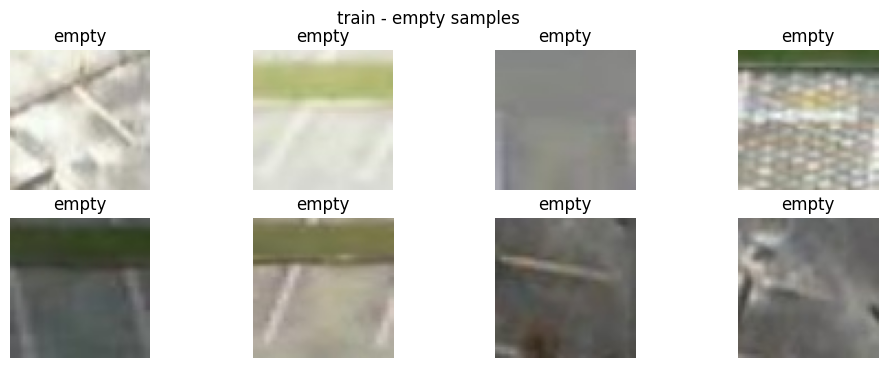

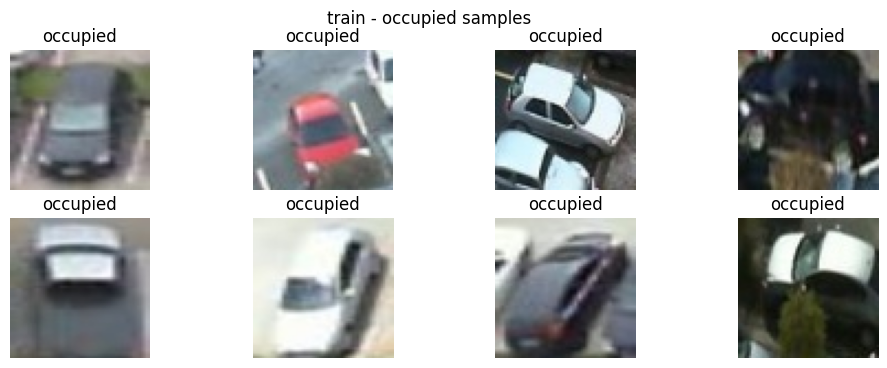

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import random

project_path = Path.cwd().parent
dataset_path = project_path / "dataset"

def show_samples(split="train", class_name="empty", n=8):
    folder = dataset_path / split / class_name
    image_paths = list(folder.glob("*.jpg"))
    
    samples = random.sample(image_paths, min(n, len(image_paths)))
    
    plt.figure(figsize=(12, 4))
    
    for i, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    
    plt.suptitle(f"{split} - {class_name} samples")
    plt.show()

show_samples("train", "empty", 8)
show_samples("train", "occupied", 8)

In [4]:
from pathlib import Path

dataset_path = Path.cwd().parent / "dataset"

for split in ["train", "valid", "test"]:
    print("=" * 40)
    print(split.upper())
    
    for class_name in ["empty", "occupied"]:
        folder = dataset_path / split / class_name
        count = len(list(folder.glob("*.jpg")))
        print(class_name, ":", count)

TRAIN
empty : 6000
occupied : 6000
VALID
empty : 1500
occupied : 1500
TEST
empty : 1500
occupied : 1500
